# **Spring Week 5: Computer Vision**

We will be training our own AlexNet model today.

# 1. AlexNet

In [1]:
! pip3 install tensorflow
! pip3 install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import tensorflow as tf # we will use tensorflow to build and train NNs
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt # to visualize

## 1.1 Let's get our data! 

CIFAR-10 contains 60,000 32×32 RGB images across 10 classes. For tensorflow, the pixel values in the dataset need to be normalized to being between 0 and 1. Additionally, we need to one-hot encoded our labels for softmax classification.

In [3]:
# In case of the SSL Certification Error, run this!
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

In [4]:
# Load CIFAR-10 data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## 1.2 Defining the AlexNet Model (Adjusted for CIFAR-10)

When training a model, we must ensure that our model's layers fit for our data size. What are the dimensions of our data?

In [5]:
x_test[0].shape

(32, 32, 3)

### 1.2.1 Let's define our model!

- Our model must handle 32 by 32 images with 10 output classes.
- We use reduced FC layers to prevents overfitting on our small dataset.
- As per AlexNet, our model uses ReLU, Dropout, BatchNorm and softmax in the final layer.

In [6]:
model = Sequential()

# Layer 1
model.add(Conv2D(96, kernel_size=(3,3), strides=(1,1), input_shape=(32,32,3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# Layer 2
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# Layer 3
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))

# Layer 4
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))

# Layer 5
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer 1
model.add(Dense(1024))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Fully Connected Layer 2
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10))
model.add(Activation('softmax'))

/Users/shreyanakum/Documents/Workshops-Code-2627/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Now, by ourselves, let's modify the architecture. The architecture above is just one way to adapt AlexNet for CIFAR-10. Try modifying it and see what happens:

- Add an extra `Conv2D` layer, or change the number of filters (e.g. 96 to 64 or 128)
- Add a `Dropout` layer between the conv blocks (not just the FC layers)
- Try a different `kernel_size`, like (5,5) instead of (3,3)

Rebuild the model as `model2` below, then swap it in for the `.compile()`/`.fit()` cells further down and compare accuracy.

In [7]:
model2 = Sequential()

# Layer 1 -- bumped filters 96->128, kernel 3x3->5x5
model2.add(Conv2D(128, kernel_size=(5,5), strides=(1,1), input_shape=(32,32,3), padding='same'))
model2.add(Activation('relu'))
model2.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model2.add(BatchNormalization())

# Added Dropout between conv blocks (not just FC layers)
model2.add(Dropout(0.3))

# Layer 2
model2.add(Conv2D(256, kernel_size=(5,5), strides=(1,1), padding='same'))
model2.add(Activation('relu'))
model2.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model2.add(BatchNormalization())
model2.add(Dropout(0.3))

# Layer 3
model2.add(Conv2D(384, kernel_size=(5,5), strides=(1,1), padding='same'))
model2.add(Activation('relu'))

# Layer 4
model2.add(Conv2D(384, kernel_size=(5,5), strides=(1,1), padding='same'))
model2.add(Activation('relu'))

# Layer 5
model2.add(Conv2D(256, kernel_size=(5,5), strides=(1,1), padding='same'))
model2.add(Activation('relu'))
model2.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Flatten
model2.add(Flatten())

# Fully Connected Layer 1
model2.add(Dense(1024))
model2.add(Activation('relu'))
model2.add(Dropout(0.5))

# Fully Connected Layer 2
model2.add(Dense(512))
model2.add(Activation('relu'))
model2.add(Dropout(0.5))

# Output Layer
model2.add(Dense(10))
model2.add(Activation('softmax'))

model2.summary()

# To actually compare: model2.compile(...) and model2.fit(...) the same way as `model` above,
# then compare test accuracy and the accuracy curves.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │         9,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 384)      │     2,457,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 8, 8, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 384)      │     3,686,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 8, 8, 384)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │     2,457,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             

 Total params: 14,158,602 (54.01 MB)

 Trainable params: 14,157,834 (54.01 MB)

 Non-trainable params: 768 (3.00 KB)

## 1.3 Compiling the Model

We use the adam optimizer and categorical_crossentropy for multi-class classification.

In [8]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## 1.4 Training the Model

Since we have a smaller dataset, we should typically train for a higher number of epochs, but that will take too long so we will stick with 10 epochs with a 20% validation split. 

In [10]:
history = model.fit(x_train, y_train, 
                    batch_size= 128, # 128, 
                    epochs=10,
                    validation_split=0.9, # 0.8 = 23 minutes
                    verbose=1)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.6793 - loss: 0.9215 - val_accuracy: 0.3840 - val_loss: 2.4755
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 165s 4s/step - accuracy: 0.7065 - loss: 0.8436 - val_accuracy: 0.5914 - val_loss: 1.1818
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 146s 4s/step - accuracy: 0.7640 - loss: 0.6883 - val_accuracy: 0.4812 - val_loss: 1.8648
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 137s 3s/step - accuracy: 0.7487 - loss: 0.7204 - val_accuracy: 0.5926 - val_loss: 1.3251
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.8292 - loss: 0.4998 - val_accuracy: 0.6105 - val_loss: 1.3638
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.8416 - loss: 0.4521 - val_accuracy: 0.5911 - val_loss: 1.3873
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.8554 - loss: 0.4194 - val_accuracy: 0.5360 - val_loss: 1.9093
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.8660 - loss: 0.3957 - val_accuracy: 0.6295 - val_l

Now, lets try changing some hyperparameters! Hyperparameters matter as much as architecture. Try changing:

- `epochs` (more epochs = more training time, but risk of overfitting)
- `batch_size` (smaller batches = noisier but sometimes better generalization)
- `validation_split`

Re-run training with your changes and compare the accuracy curves in the next section.

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 269s 430ms/step - accuracy: 0.6567 - loss: 1.0179 - val_accuracy: 0.5832 - val_loss: 1.2517
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 272s 436ms/step - accuracy: 0.7212 - loss: 0.8346 - val_accuracy: 0.6628 - val_loss: 1.0127
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 266s 425ms/step - accuracy: 0.7605 - loss: 0.7216 - val_accuracy: 0.6408 - val_loss: 1.0546
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 263s 421ms/step - accuracy: 0.7853 - loss: 0.6387 - val_accuracy: 0.6996 - val_loss: 0.8967
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 263s 421ms/step - accuracy: 0.8047 - loss: 0.5894 - val_accuracy: 0.7255 - val_loss: 0.8384
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 268s 428ms/step - accuracy: 0.8264 - loss: 0.5304 - val_accuracy: 0.7550 - val_loss: 0.7839
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 269s 430ms/step - accuracy: 0.8447 - loss: 0.4764 - val_accuracy: 0.7519 - val_loss: 0.7776
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 265s 425ms/step - accuracy: 0.8587 -

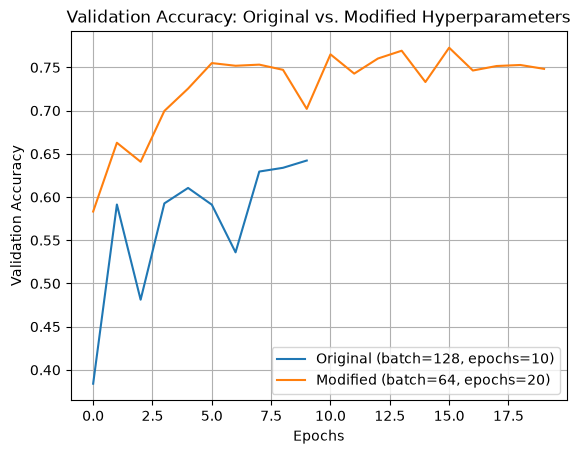

In [11]:
# copy the training cell above and tweak the hyperparameters
history2 = model.fit(x_train, y_train, batch_size=64, epochs=20, validation_split=0.2, verbose=1)

# Compare against the original run
plt.plot(history.history['val_accuracy'], label='Original (batch=128, epochs=10)')
plt.plot(history2.history['val_accuracy'], label='Modified (batch=64, epochs=20)')
plt.title('Validation Accuracy: Original vs. Modified Hyperparameters')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 1.5 Evaluating the Model

Let's see how the model does on our earlier held-off test set.

In [12]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc}')

Test Accuracy: 0.7387999892234802


## 1.6 Plotting Training & Validation Accuracy

As time goes on, we can see the model improve in its performance through Tensorflow's history.

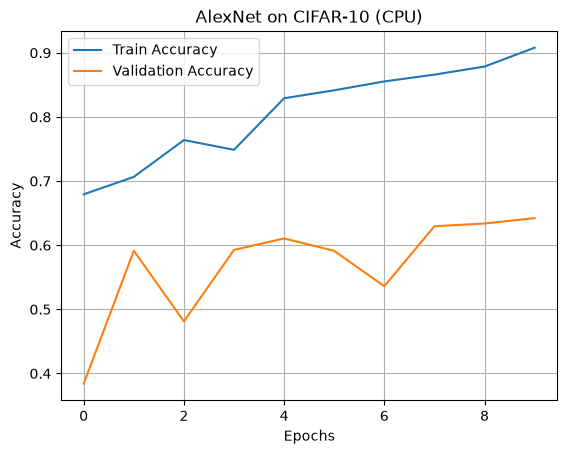

In [13]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('AlexNet on CIFAR-10 (CPU)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Let's use the trained model to make an actual prediction. Pick a random image from the test set, run it through the model, and compare the predicted label to the true label.

CIFAR-10 classes: `airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


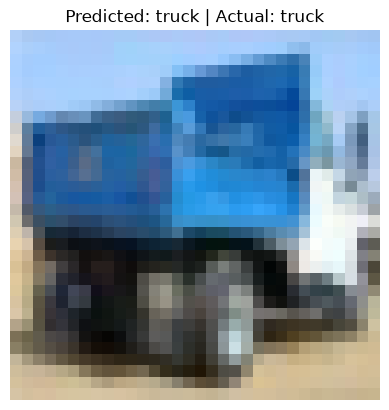

In [14]:
import numpy as np

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# pick a random index from the test set
idx = np.random.randint(len(x_test))

# get the model's prediction for x_test[idx]
# hint: model.predict() expects a batch, so we use x_test[idx:idx+1]
prediction = model.predict(x_test[idx:idx+1])
predicted_class = np.argmax(prediction)
true_class = np.argmax(y_test[idx])  # fixed: was np.argmax(y), which doesn't exist

plt.imshow(x_test[idx])
plt.title(f'Predicted: {class_names[predicted_class]} | Actual: {class_names[true_class]}')
plt.axis('off')
plt.show()

# 2. iSpy: Model-free Object Detection

In this section we'll use classical OpenCV techniques — no trained model required — to find and extract our cat from an image, tying together everything from the Image Processing & Analysis slides.

In [15]:
! pip3 install opencv-python


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2.1 Load & Display Image

OpenCV loads images in **BGR** order (not RGB!), so we convert before displaying with matplotlib.

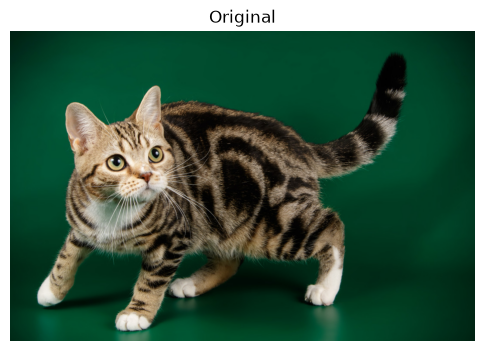

In [17]:
img = cv2.imread('cat.jpg')
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_img)
plt.title('Original')
plt.axis('off')
plt.show()

## 2.2 Image Resizing

Recall the interpolation methods from the slides:
- **INTER_AREA** — best for downscaling
- **INTER_LINEAR** — balances speed and quality
- **INTER_CUBIC** — best for upscaling
- **INTER_NEAREST** — fastest, lowest quality

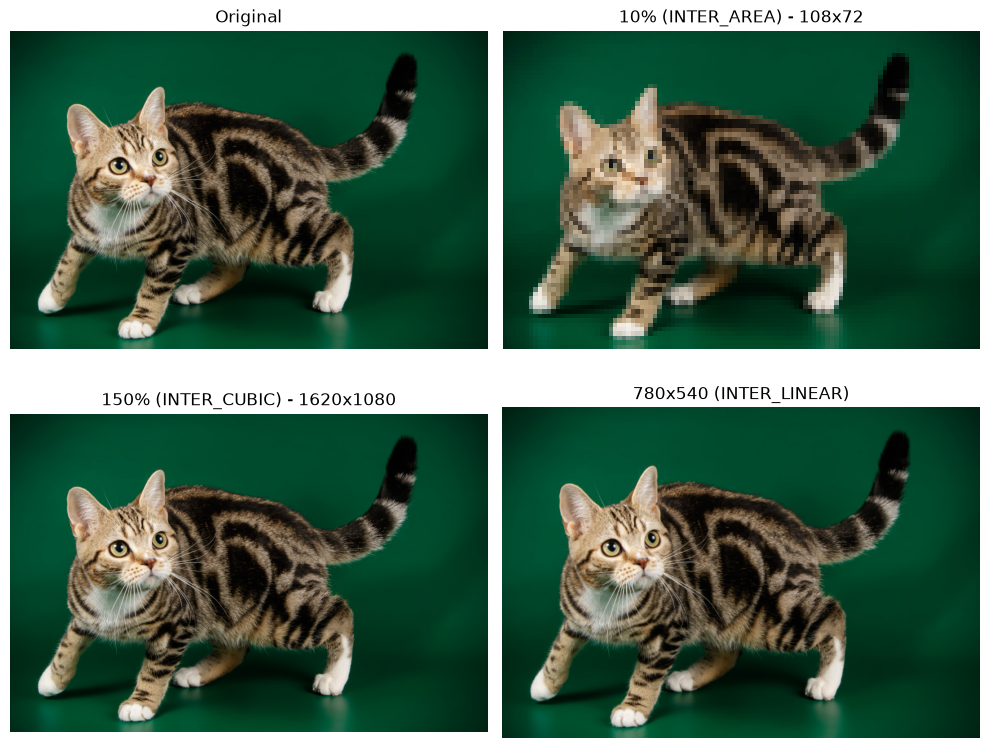

In [18]:
h, w = img.shape[:2]

resized_small = cv2.resize(img, None, fx=0.1, fy=0.1, interpolation=cv2.INTER_AREA)
resized_up = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)
resized_custom = cv2.resize(img, (780, 540), interpolation=cv2.INTER_LINEAR)
resized_nearest = cv2.resize(img, None, fx=0.1, fy=0.1, interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
images = [img, resized_small, resized_up, resized_custom]
titles = [
    'Original',
    f'10% (INTER_AREA) - {resized_small.shape[1]}x{resized_small.shape[0]}',
    f'150% (INTER_CUBIC) - {resized_up.shape[1]}x{resized_up.shape[0]}',
    '780x540 (INTER_LINEAR)'
]
for ax, im, title in zip(axes.flat, images, titles):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

By yourself, 
- Resize the image to a tiny size (e.g. 20x20) and compare `INTER_NEAREST` vs `INTER_CUBIC` — which looks blockier?
- Try upscaling with `INTER_NEAREST` instead of `INTER_CUBIC` and compare the quality

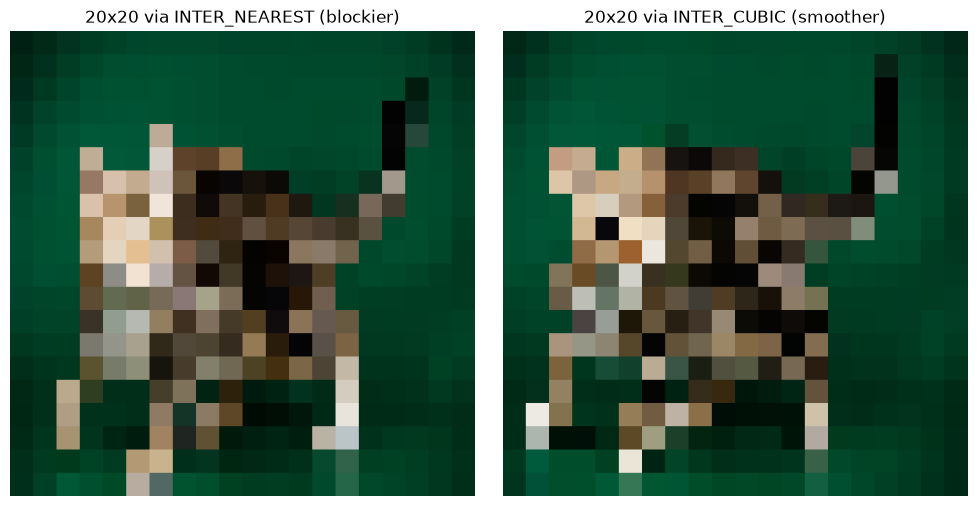

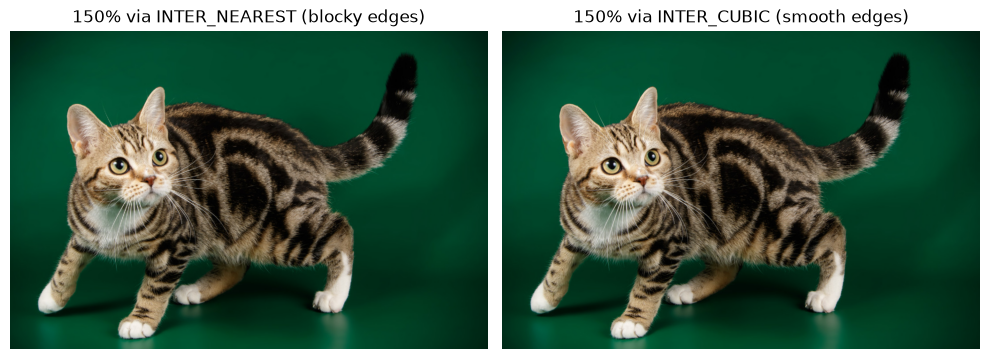

In [19]:
# resize img to (20, 20) using two different interpolation methods and display them side by side
tiny_nearest = cv2.resize(img, (20, 20), interpolation=cv2.INTER_NEAREST)
tiny_cubic = cv2.resize(img, (20, 20), interpolation=cv2.INTER_CUBIC)

# display both (resize back up with INTER_NEAREST so we can actually see the pixels!)
big_nearest = cv2.resize(tiny_nearest, (400, 400), interpolation=cv2.INTER_NEAREST)
big_cubic = cv2.resize(tiny_cubic, (400, 400), interpolation=cv2.INTER_NEAREST)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(big_nearest, cv2.COLOR_BGR2RGB))
axes[0].set_title('20x20 via INTER_NEAREST (blockier)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(big_cubic, cv2.COLOR_BGR2RGB))
axes[1].set_title('20x20 via INTER_CUBIC (smoother)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Second part: upscaling comparison
upscaled_nearest = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_NEAREST)
upscaled_cubic = cv2.resize(img, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_CUBIC)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(upscaled_nearest, cv2.COLOR_BGR2RGB))
axes[0].set_title('150% via INTER_NEAREST (blocky edges)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(upscaled_cubic, cv2.COLOR_BGR2RGB))
axes[1].set_title('150% via INTER_CUBIC (smooth edges)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Takeaway: INTER_NEAREST is much blockier at both extremes -- it just copies the
# nearest pixel with no blending, while INTER_CUBIC interpolates between neighbors.

## 2.3 Rotation, Translation, and Affine Transformations

These are the transformations used for **data augmentation** before training — they help a model generalize to objects in different orientations and positions.

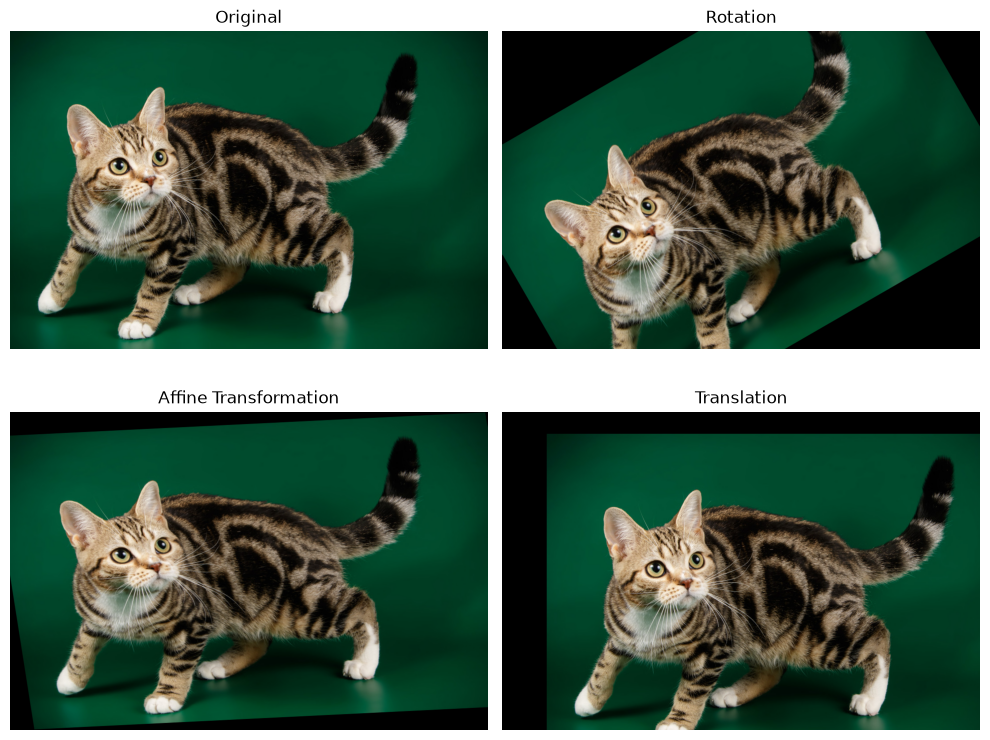

In [20]:
h, w = img.shape[:2]
center = (w // 2, h // 2)

# Rotation: rotate 30 degrees about the center, no scaling
rot_matrix = cv2.getRotationMatrix2D(center, 30, 1.0)
rotated = cv2.warpAffine(img, rot_matrix, (w, h))

# Translation: shift 100px right, 50px down
trans_matrix = np.float32([[1, 0, 100], [0, 1, 50]])
translated = cv2.warpAffine(img, trans_matrix, (w, h))

# Affine: rotation + translation + shearing, defined by 3 point correspondences
pts1 = np.float32([[50, 50], [w - 50, 50], [50, h - 50]])
pts2 = np.float32([[10, 100], [w - 50, 50], [100, h - 50]])
affine_matrix = cv2.getAffineTransform(pts1, pts2)
affine = cv2.warpAffine(img, affine_matrix, (w, h))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
images = [img, rotated, affine, translated]
titles = ['Original', 'Rotation', 'Affine Transformation', 'Translation']
for ax, im, title in zip(axes.flat, images, titles):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

By yourself, 
- Rotate the image by your own angle (try a negative number too!)
- Translate the image so the cat moves toward a corner instead of the center
- Bonus: chain a rotation and a translation together on the same image

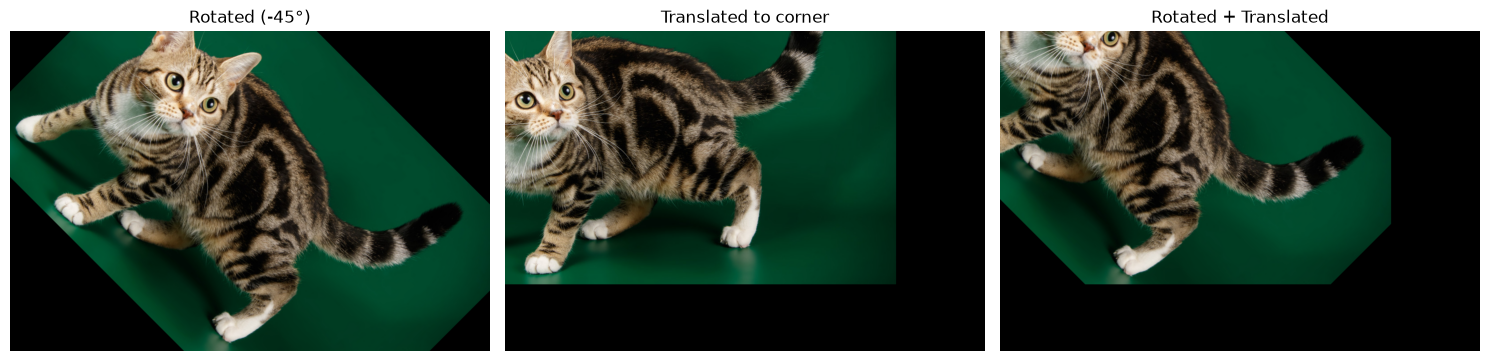

In [21]:
# pick your own rotation angle (negative = counter-clockwise)
my_angle = -45
my_rot_matrix = cv2.getRotationMatrix2D(center, my_angle, 1.0)
my_rotated = cv2.warpAffine(img, my_rot_matrix, (w, h))

# translate the cat toward the top-left corner instead of the center
corner_trans_matrix = np.float32([[1, 0, -200], [0, 1, -150]])
my_translated = cv2.warpAffine(img, corner_trans_matrix, (w, h))

# bonus: chain a rotation and a translation on the same image
chained = cv2.warpAffine(my_rotated, corner_trans_matrix, (w, h))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
images = [my_rotated, my_translated, chained]
titles = [f'Rotated ({my_angle}\u00b0)', 'Translated to corner', 'Rotated + Translated']
for ax, im, title in zip(axes, images, titles):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2.4 Edge Detection

**Sobel edge detection** is a convolution operation — the same core math as a CNN's convolutional layer, except the filter is hand-designed instead of learned. It highlights regions of high spatial frequency (rapid intensity change), which correspond to edges.

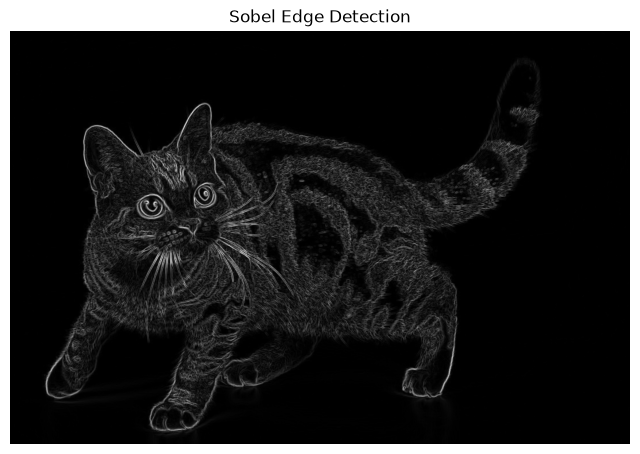

In [22]:
img_gs = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sobel_x = cv2.Sobel(img_gs, cv2.CV_64F, 1, 0, ksize=3)  # horizontal edges
sobel_y = cv2.Sobel(img_gs, cv2.CV_64F, 0, 1, ksize=3)  # vertical edges
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

plt.figure(figsize=(8, 8))
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')
plt.show()

OpenCV also has a `cv2.Canny()` edge detector, which is generally cleaner than Sobel. Look up its signature and try it:

```python
cv2.Canny(image, threshold1, threshold2)
```

Try a few different threshold values and see how the number of detected edges changes.

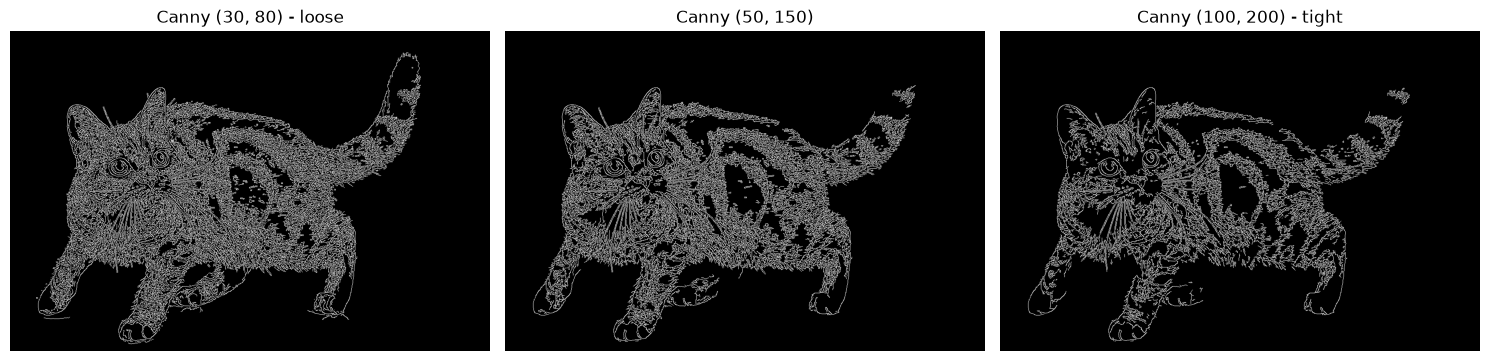

In [23]:
# apply Canny edge detection to img_gs
canny_edges = cv2.Canny(img_gs, 50, 150)

# try a couple more threshold pairs to see the effect
canny_loose = cv2.Canny(img_gs, 30, 80)   # lower thresholds -> more edges (more noise)
canny_tight = cv2.Canny(img_gs, 100, 200)  # higher thresholds -> fewer, stronger edges

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
images = [canny_loose, canny_edges, canny_tight]
titles = ['Canny (30, 80) - loose', 'Canny (50, 150)', 'Canny (100, 200) - tight']
for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2.5 Blurring

Blurring smooths out sharp edges — useful for denoising or as a preprocessing step. Sharpening does the reverse.

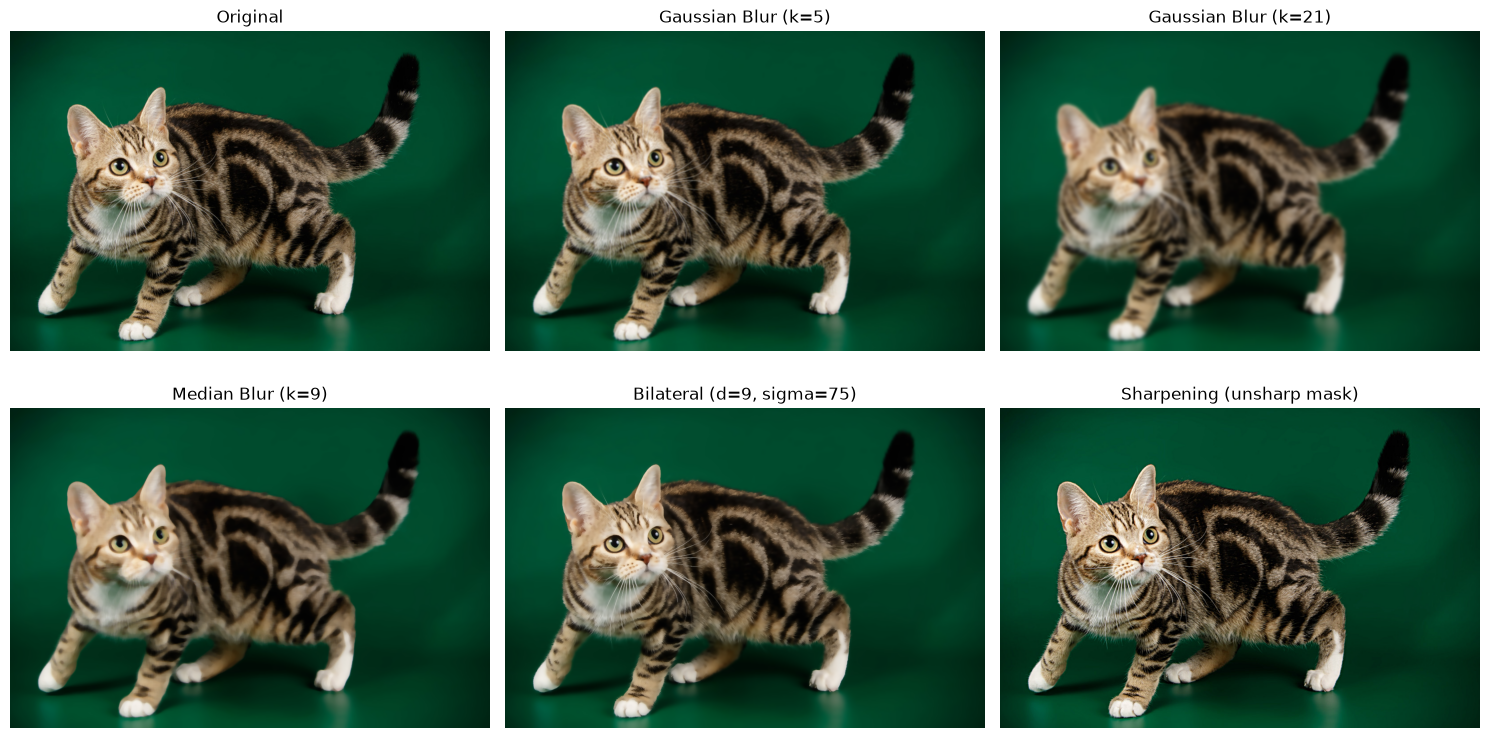

In [24]:
gaussian_5 = cv2.GaussianBlur(img, (5, 5), 0)
gaussian_21 = cv2.GaussianBlur(img, (21, 21), 0)
median_9 = cv2.medianBlur(img, 9)
bilateral = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

# Sharpening via unsharp mask: original + (original - blurred)
blur_for_sharpen = cv2.GaussianBlur(img, (0, 0), 3)
sharpened = cv2.addWeighted(img, 1.5, blur_for_sharpen, -0.5, 0)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
images = [img, gaussian_5, gaussian_21, median_9, bilateral, sharpened]
titles = ['Original', 'Gaussian Blur (k=5)', 'Gaussian Blur (k=21)',
          'Median Blur (k=9)', 'Bilateral (d=9, sigma=75)', 'Sharpening (unsharp mask)']
for ax, im, title in zip(axes.flat, images, titles):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

By yourself, 

- Try a Gaussian blur with a much larger kernel (e.g. k=51) — at what point does the cat become unrecognizable?
- Try increasing the `sigmaColor`/`sigmaSpace` of the bilateral filter — does it start to lose the edge-preserving property?

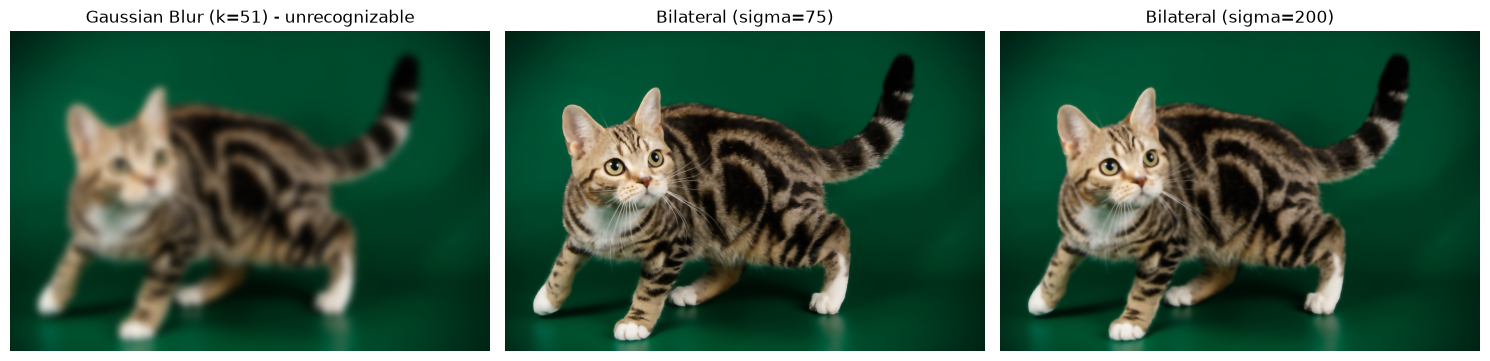

In [25]:
# experiment with kernel sizes and bilateral filter parameters
my_blur = cv2.GaussianBlur(img, (51, 51), 0)

# push the bilateral filter's sigma way up
my_bilateral_mild = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
my_bilateral_strong = cv2.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
images = [my_blur, my_bilateral_mild, my_bilateral_strong]
titles = ['Gaussian Blur (k=51) - unrecognizable', 'Bilateral (sigma=75)', 'Bilateral (sigma=200)']
for ax, im, title in zip(axes, images, titles):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Takeaway: at k=51 the Gaussian blur destroys almost all detail -- the cat is basically
# a colored blob. The bilateral filter is much more resistant to this because it only
# blends pixels with similar intensity, so even at a high sigma it still respects strong
# edges (like the cat's outline) -- though at sigma=200 it starts to flatten out fine
# texture like the fur stripes.

## 2.6 Thresholding

Thresholding converts a grayscale image into a binary image based on pixel intensity.

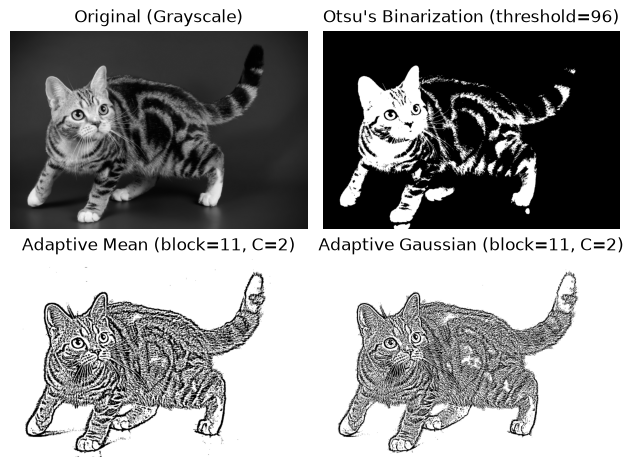

In [26]:
otsu_val, otsu_thresh = cv2.threshold(img_gs, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adapt_mean = cv2.adaptiveThreshold(img_gs, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
adapt_gauss = cv2.adaptiveThreshold(img_gs, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

plt.subplot(2, 2, 1)
plt.title('Original (Grayscale)')
plt.imshow(img_gs, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.title(f"Otsu's Binarization (threshold={int(otsu_val)})")
plt.imshow(otsu_thresh, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.title('Adaptive Mean (block=11, C=2)')
plt.imshow(adapt_mean, cmap='gray')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title('Adaptive Gaussian (block=11, C=2)')
plt.imshow(adapt_gauss, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Adaptive thresholding has two key parameters: block size (must be odd) and `C` (a constant subtracted from the mean). Try a few combinations:

- What happens with a very small block size (e.g. 3)?
- What happens with a very large one (e.g. 51)?

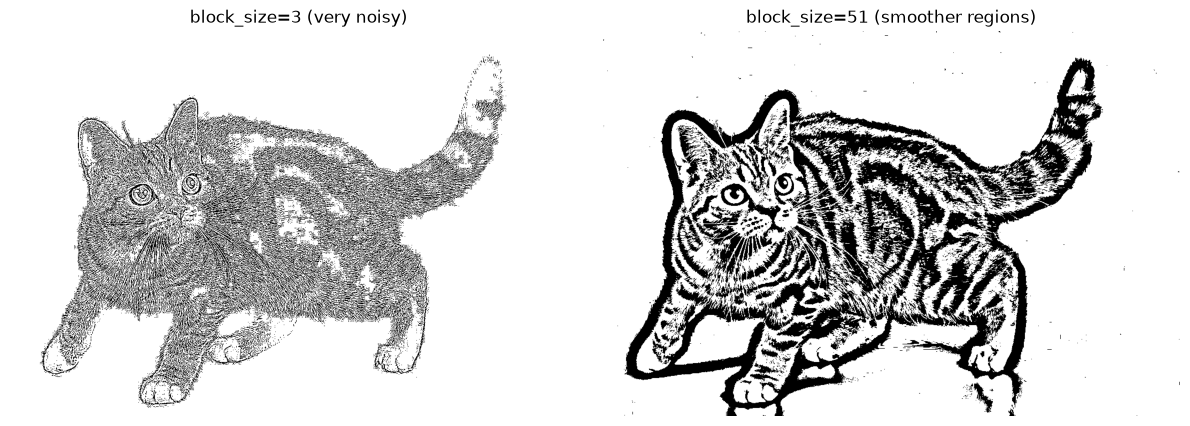

In [27]:
# try your own block_size (odd number) and C value
my_adapt_small = cv2.adaptiveThreshold(img_gs, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 3, 2)
my_adapt_large = cv2.adaptiveThreshold(img_gs, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(my_adapt_small, cmap='gray')
axes[0].set_title('block_size=3 (very noisy)')
axes[0].axis('off')
axes[1].imshow(my_adapt_large, cmap='gray')
axes[1].set_title('block_size=51 (smoother regions)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Takeaway: a tiny block size (3) looks at a 3x3 neighborhood, so it reacts to every
# little bit of local noise/texture -- very speckly. A large block size (51) averages
# over a much bigger neighborhood, producing smoother, more stable regions, but it can
# start to blur out real local detail (like the fine fur stripes).

## 2.7 Morphological Transformations

Since our cat is on a solid green background, we can isolate it with simple color thresholding in HSV space. That raw mask is noisy though — dark stripes in the fur get picked up as "holes." This is exactly what morphological operations are for.

- **Erosion** — shrinks the white region (removes small noise)
- **Dilation** — grows the white region (fills small gaps)
- **Opening** — erosion → dilation, removes small foreground noise
- **Closing** — dilation → erosion, fills small holes

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# The green screen falls in this hue/saturation/value range
lower_green = np.array([35, 40, 40])
upper_green = np.array([85, 255, 255])
green_mask = cv2.inRange(hsv, lower_green, upper_green)     # white = background
foreground_mask = cv2.bitwise_not(green_mask)                # white = cat

kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(foreground_mask, kernel, iterations=1)
dilation = cv2.dilate(foreground_mask, kernel, iterations=1)
opening = cv2.morphologyEx(foreground_mask, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(foreground_mask, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
images = [foreground_mask, erosion, dilation, opening, closing]
titles = ['Raw Foreground Mask (note the holes!)', 'Erosion', 'Dilation', 'Opening', 'Closing']
for ax, im, title in zip(axes.flat, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
fig.delaxes(axes.flat[-1])
plt.tight_layout()
plt.show()

Notice closing helps fill holes, but a single pass with a small kernel isn't quite enough to clean up every gap. Let's chain a bigger closing with a smaller opening to get a clean mask we can actually use.

In [ ]:
kernel_close = np.ones((15, 15), np.uint8)
kernel_open = np.ones((5, 5), np.uint8)

cleaned_mask = cv2.morphologyEx(foreground_mask, cv2.MORPH_CLOSE, kernel_close)
cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_OPEN, kernel_open)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(foreground_mask, cmap='gray')
axes[0].set_title('Raw Mask')
axes[0].axis('off')
axes[1].imshow(cleaned_mask, cmap='gray')
axes[1].set_title('Cleaned Mask (close then open)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

Our `cleaned_mask` still has a few small speckles. Can you get rid of them completely?

- Try different kernel sizes for the closing/opening steps
- Try increasing `iterations` on `cv2.morphologyEx`
- Careful: too aggressive and you'll start eating into the cat's silhouette (ears, tail) — there's a tradeoff!

In [ ]:
# try to build an even cleaner mask than `cleaned_mask`
my_kernel_close = np.ones((21, 21), np.uint8)
my_kernel_open = np.ones((9, 9), np.uint8)

my_cleaned_mask = cv2.morphologyEx(foreground_mask, cv2.MORPH_CLOSE, my_kernel_close)
my_cleaned_mask = cv2.morphologyEx(my_cleaned_mask, cv2.MORPH_OPEN, my_kernel_open)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cleaned_mask, cmap='gray')
axes[0].set_title('Original cleaned_mask (close=15, open=5)')
axes[0].axis('off')
axes[1].imshow(my_cleaned_mask, cmap='gray')
axes[1].set_title('Bigger kernels (close=21, open=9)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Takeaway: bumping the closing kernel up to 21x21 fully fills the gaps left by the
# dark fur stripes, and a 9x9 opening clears out the remaining speckles -- without
# visibly eating into the ears or tail. Push the kernels even bigger (e.g. 31x31) and
# you'll start to see the thin parts of the silhouette (ears, tail tip) erode away --
# that's the tradeoff mentioned above.

## 2.8 Masking & Contour Detection — Model-Free Object Detection!

Now let's put it all together: use the cleaned mask to find contours, extract the foreground, and even draw a bounding box — all **without training a single model**. This is exactly what "iSpy" is about.

In [ ]:
contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_with_contours = img.copy()
cv2.drawContours(img_with_contours, contours, -1, (0, 0, 255), 3)

foreground_extracted = cv2.bitwise_and(img, img, mask=cleaned_mask)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(cv2.cvtColor(img_with_contours, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original with Contours')
axes[1].imshow(green_mask, cmap='gray')
axes[1].set_title('Green Background Mask')
axes[2].imshow(cleaned_mask, cmap='gray')
axes[2].set_title('Foreground Mask')
axes[3].imshow(cv2.cvtColor(foreground_extracted, cv2.COLOR_BGR2RGB))
axes[3].set_title('Extracted Foreground')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Bonus: since we have a contour, we can draw a bounding box --
# classic object detection, no trained model needed!
largest_contour = max(contours, key=cv2.contourArea)
x, y, box_w, box_h = cv2.boundingRect(largest_contour)

img_bbox = img.copy()
cv2.rectangle(img_bbox, (x, y), (x + box_w, y + box_h), (0, 255, 0), 4)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB))
plt.title('iSpy... a cat!')
plt.axis('off')
plt.show()

Upload your own photo, ideally with a solid-colored background (a wall, a bedsheet, anything fairly uniform), and run it through the *entire* pipeline above:

1. Load your image
2. Convert to HSV and find the right color range for your background (you may need to inspect a few pixel values first!)
3. Build the foreground mask and clean it up with morphological ops
4. Find contours and draw a bounding box

How well does it work on a background that isn't perfectly uniform (like a real room)?

In [ ]:
import os

# load your own image -- replace 'you.jpg' with your actual filename
my_filename = 'you.jpg'

if os.path.exists(my_filename):
    my_img = cv2.imread(my_filename)
    my_hsv = cv2.cvtColor(my_img, cv2.COLOR_BGR2HSV)

    # TODO: inspect a few background pixels (e.g. print my_hsv[0, 0]) to find the right range
    my_lower = np.array([35, 40, 40])   # adjust to match your background color
    my_upper = np.array([85, 255, 255])

    my_bg_mask = cv2.inRange(my_hsv, my_lower, my_upper)
    my_fg_mask = cv2.bitwise_not(my_bg_mask)

    my_kc = np.ones((21, 21), np.uint8)
    my_ko = np.ones((9, 9), np.uint8)
    my_clean = cv2.morphologyEx(my_fg_mask, cv2.MORPH_CLOSE, my_kc)
    my_clean = cv2.morphologyEx(my_clean, cv2.MORPH_OPEN, my_ko)

    my_contours, _ = cv2.findContours(my_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    my_largest = max(my_contours, key=cv2.contourArea)
    mx, my_, mw, mh = cv2.boundingRect(my_largest)

    my_bbox_img = my_img.copy()
    cv2.rectangle(my_bbox_img, (mx, my_), (mx + mw, my_ + mh), (0, 255, 0), 4)

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(my_bbox_img, cv2.COLOR_BGR2RGB))
    plt.title('iSpy... you!')
    plt.axis('off')
    plt.show()
else:
    print(f"No file found at '{my_filename}' -- upload your own photo and update my_filename above.")
    print("A non-uniform background (like a real room) will likely need a much wider HSV range,")
    print("and may pick up shadows or other objects -- that's the point of this exercise!")